---
# **Práctica 2**: *Propiedades estadísticas del lenguaje y Diversidad*
---
### **Alumno**:  Roberto Samuel Sanchez Rosas

##**1. Verificación empírica de la Ley de Zipf**

Verificar si la ley de Zipf se cumple en los siguientes casos:

1. En un lenguaje artificial creado por ustedes.
    * Creen un script que genere un texto aleatorio seleccionando caracteres al azar de un alfabeto definido.
        * **Nota:** Asegúrense de incluir el carácter de "espacio" en su alfabeto para que el texto se divida en "palabras" de longitudes variables.
    * Obtengan las frecuencias de las palabras generadas para este texto artificial
2. Alguna lengua de bajos recursos digitales (*low-resourced language*)
    * Busca un corpus de libre acceso en alguna lengua de bajos recursos digitales
    * Obten las frecuencias de sus palabras

En ambos casos realiza lo siguiente:
* Estima el parámetro $\alpha$ que mejor se ajuste a la curva
* Generen las gráficas de rango vs. frecuencia (en escala y logarítmica).
    * Incluye la recta aproximada por $\alpha$

In [1]:
import random
import string

def generar_texto_artificial(longitud_texto=1000000, alfabeto=string.ascii_lowercase):
    # Aseguramos que el alfabeto tenga el caracter de espacio.
    alfabeto_con_espacio = alfabeto if ' ' in alfabeto else alfabeto + ' '
    # Obtenemos texto al seleccionar caracteres al azar del alfabeto, las palabras se
    # formaran cuando se tome un espacio entre una secuencia de otras letras
    return ''.join(random.choice(alfabeto_con_espacio) for _ in range(longitud_texto))

def separar_palabras_texto(texto: str):
  return texto.replace("\n", " ").split(" ")


In [2]:
texto_artificial = generar_texto_artificial()
palabras = separar_palabras_texto(texto_artificial)

In [3]:
from collections import Counter
conteo_palabras = Counter(palabras)

In [4]:
conteo_palabras.most_common(10)

[('', 1330),
 ('c', 72),
 ('x', 62),
 ('y', 61),
 ('p', 60),
 ('b', 60),
 ('o', 60),
 ('q', 58),
 ('n', 58),
 ('t', 55)]

In [5]:
import matplotlib.pyplot as plt

def get_frequencies(vocabulary: Counter, n: int) -> list:
    return [_[1] for _ in vocabulary.most_common(n)]

def plot_frequencies(frequencies: list, title="Freq of words", log_scale=False):
    x = list(range(1, len(frequencies) + 1))
    plt.plot(x, frequencies, "-v")
    plt.xlabel("Freq rank (r)")
    plt.ylabel("Freq (f)")
    if log_scale:
        plt.xscale("log")
        plt.yscale("log")
    plt.title(title)

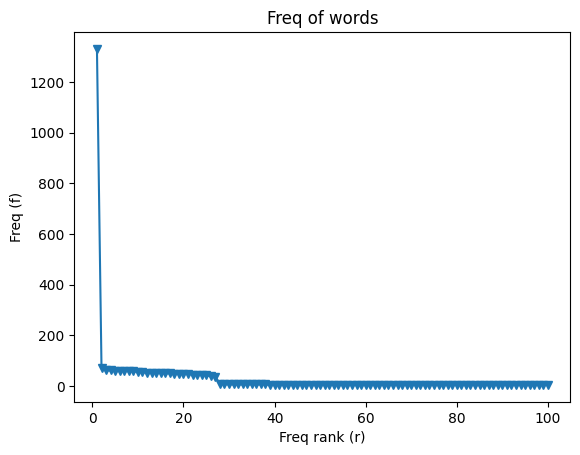

In [6]:
frequencies = get_frequencies(conteo_palabras, 100)
plot_frequencies(frequencies)

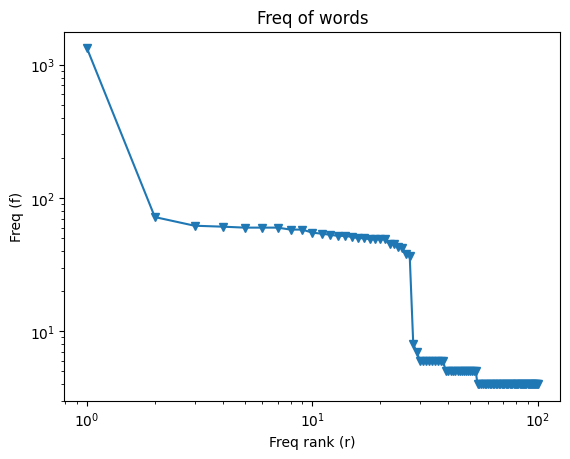

In [7]:
plot_frequencies(frequencies, log_scale=True)

In [8]:
pip install elotl

In [9]:
import elotl.corpus

print("Name\t\tDescription")
list_of_corpus = elotl.corpus.list_of_corpus()
for row in list_of_corpus:
    print(row)

Name		Description
['axolotl', 'Is a Spanish-Nahuatl parallel corpus']
['tsunkua', 'Is a Spanish-Otomí parallel corpus']
['kolo', 'Is a Spanish-Mixteco parallel corpus']


In [10]:
axolotl = elotl.corpus.load('axolotl')

In [11]:
def juntar_texto_corpus(corpus, n=0):
  if n < 0:
    n = 0
  elif n > len(corpus):
    n = len(corpus)
  return " ".join([_[1] for _ in corpus])

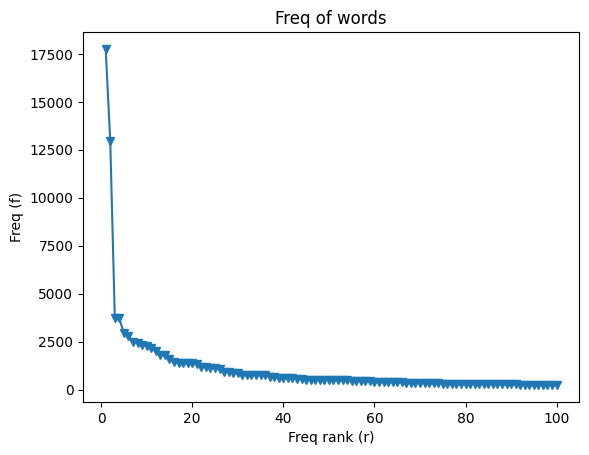

In [12]:
palabras_nahuatl = separar_palabras_texto(juntar_texto_corpus(axolotl))

conteo_palabras_nahuatl = Counter(palabras_nahuatl)

frequencies_nahuatl = get_frequencies(conteo_palabras_nahuatl, 100)

plot_frequencies(frequencies_nahuatl)

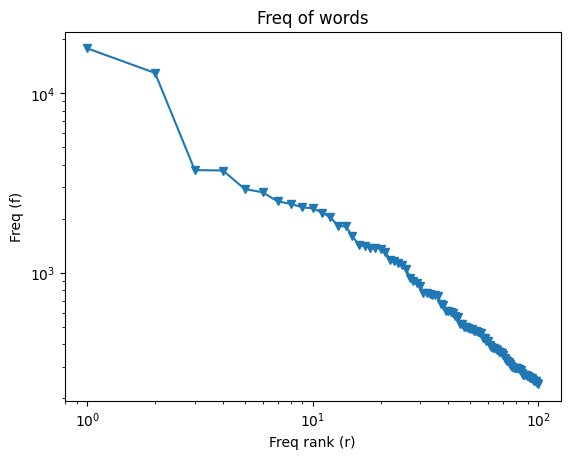

In [13]:
plot_frequencies(frequencies_nahuatl, log_scale=True)

In [14]:
import pandas as pd

def counter_to_pandas(counter: Counter) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(counter, orient="index").reset_index()
    df.columns = ["word", "count"]
    df.sort_values("count", ascending=False, inplace=True)
    df.reset_index(inplace=True, drop=True)
    return df

In [15]:
corpus_freqs_nahuatl = counter_to_pandas(conteo_palabras_nahuatl)
corpus_freqs = counter_to_pandas(conteo_palabras)

In [16]:
import numpy as np
from scipy.optimize import minimize

def zipf_minimization_objective(alpha: np.float64,
                               word_ranks: np.ndarray,
                               word_frequencies: np.ndarray) -> np.float64:
    """
    Calculate the sum of squared errors for Zipf's law fit.

    Parameters
    ----------
    alpha : np.float64
        The exponent parameter to optimize in Zipf's law
    word_ranks : np.ndarray
        Array of word ranks (1 = most frequent word)
    word_frequencies : np.ndarray
        Array of observed word frequencies

    Returns
    -------
    np.float64
        Sum of squared errors between log frequencies and Zipf's law prediction
    """
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

In [17]:
def plot_generate_zipf(alpha: np.float64, ranks: np.ndarray, freqs: np.ndarray) -> None:
    plt.plot(
        np.log(ranks),
        np.log(freqs[0]) - alpha * np.log(ranks),
        color="r",
        label="Aproximación Zipf",
    )

In [18]:
def plot_zipf(corpus_freqs):
  # Obtenemos los ranks y las frecuencias del corpus
  # +1 para hacer que los ranks inicien en 1 y no en 0
  ranks = np.array(corpus_freqs.index) + 1
  frequencies = np.array(corpus_freqs["count"])

  # Parámeto alfa inicial
  initial_alpha_guess = 1.0

  optimization_result = minimize(
      zipf_minimization_objective,
      initial_alpha_guess,
      args=(ranks, frequencies)
  )
  estimated_alpha = optimization_result.x[0]

  mean_squared_error = zipf_minimization_objective(estimated_alpha, ranks, frequencies)
  print(f"Estimated alpha: {estimated_alpha:.4f}\nMean Squared Error: {mean_squared_error:.4f}")


  plot_generate_zipf(estimated_alpha, ranks, frequencies)
  plt.plot(np.log(ranks), np.log(frequencies), color="b", label="Distribución real")
  plt.xlabel("log ranks")
  plt.ylabel("log frecs")
  plt.legend(bbox_to_anchor=(1, 1))
  plt.show()

Estimated alpha: 0.9294
Mean Squared Error: 6788.7651


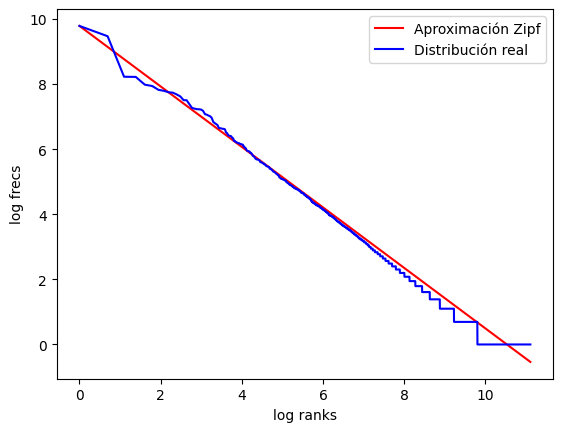

In [19]:
plot_zipf(corpus_freqs_nahuatl)

Estimated alpha: 0.7537
Mean Squared Error: 16396.3564


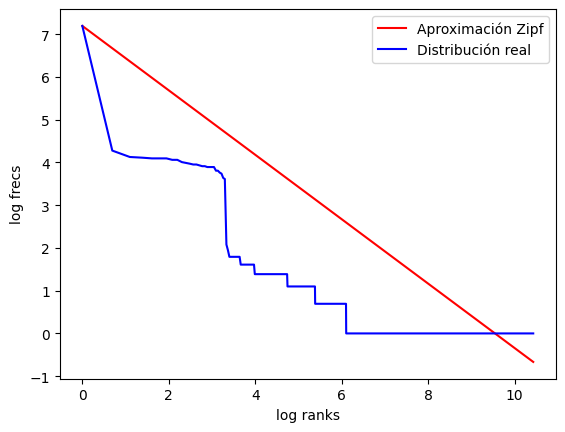

In [20]:
plot_zipf(corpus_freqs)

### ¿Se aproxima a la ley de Zipf?
Podemos observar que la gráfica del nahuatl sí es una muy buena aproximaxion pues en la de log-log tenemos casí una recta en la distribución real.

Por otro lado para la gráfica del lenguaje generado de manera aleatoria observamos que si bien no se aproximan como en la del nahuatl o la vista en la clase del laboratorio, sí podemos ver cierta diferencia sobre todo en la palabra mas común, pues inmediatamente se disminuye la frecuencia por lo cual podemos ver en la gráfica de frecuencia la "forma" de zipf.  

---
## **2. Visualizando la diversidad lingüística de México**

1. Usando los datos de Glottolog filtralos con base en la región geográfica que corresponde a México
    - Usa las columnas `"longitude"` y `"latitude"`
2. Realiza un plot de las lenguas por región de un mapa
    - Utiliza un color por familia linguistica en el mapa
3. Haz lo mismo para otro país del mundo

In [22]:
import plotly.express as px
import os

# Se asume que se han descargado los archivo y que se encuentra en la carpeta data/
DATA_PATH = "data"
LANG_GEO_FILE = "languages_and_dialects_geo.csv"
LANGUOID_FILE = "languoid.csv"

# Cargamos los datos de Glottolog
df = pd.read_csv(os.path.join(DATA_PATH, LANGUOID_FILE))

# Nos aseguramos que latitud y longitud sean numéricos y quitamos los que no tienen coordenadas
df = df.dropna(subset=['latitude', 'longitude'])
df['latitude'] = pd.to_numeric(df['latitude'])
df['longitude'] = pd.to_numeric(df['longitude'])

# Filtramos por las coordenadas aproximadas de México
min_lat = 14.5
max_lat = 32.7
min_long = -118.4
max_long = -86.8

df_mexico = df[
    (df['latitude'] >= min_lat) & (df['latitude'] <= max_lat) &
    (df['longitude'] >= min_long) & (df['longitude'] <= -86.8)
]

# Mapa interactivo de México
fig_mexico = px.scatter_mapbox(
    df_mexico,
    lat="latitude",
    lon="longitude",
    color="family_id", # Un color distinto por familia lingüística
    hover_name="name", # Al pasar el mouse se verá el nombre de la lengua
    title="Diversidad Lingüística en México por Familia",
    mapbox_style="carto-positron", # Estilo de mapa
    zoom=4
)


In [23]:
fig_mexico.show()

In [24]:
# Filtramos por las coordenadas aproximadas de Papúa Nueva Guinea
min_lat_png = -11.6
max_lat_png = -1.0
min_long_png = 140.8
max_long_png = 156.0

df_png = df[
    (df['latitude'] >= min_lat_png) & (df['latitude'] <= max_lat_png) &
    (df['longitude'] >= min_long_png) & (df['longitude'] <= max_long_png)
]

fig_png = px.scatter_mapbox(
    df_png,
    lat="latitude",
    lon="longitude",
    color="family_id",
    hover_name="name",
    title="Diversidad Lingüística en Papúa Nueva Guinea",
    mapbox_style="carto-positron",
    zoom=4
)
fig_png.show()

- ¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?

México es uno de los paises con mas diversidad lingüistica en el mundo, aunque podemos ver que hay mas diversidad en el mapa de Papúa Nueva Guinea, pero esto es debido a que este país es el que tiene mas diversidad en el mundo.

- ¿Cuál es la zona que dirias que tiene mayor diversidad en México?

Podemos ver en el mapa de diversidad lingúistica en México que la zona sur es la que tiene mayor diversidad, exactamente en el estado de Oaxaca.